In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sea

In [2]:
df = pd.read_csv("List of Countries by Sugarcane Production.csv")

In [3]:
df.head()

,Unnamed: 0,Country,Continent,Production (Tons),Production per Person (Kg),Acreage (Hectare),Yield (Kg / Hectare)
0,0,Brazil,South America,768.678.382,"3.668,531",10.226.205,"75.167,5"
1,1,India,Asia,348.448.000,260721,4.950.000,"70.393,5"
2,2,China,Asia,123.059.739,88287,1.675.215,"73.459,1"
3,3,Thailand,Asia,87.468.496,"1.264,303",1.336.575,"65.442,2"
4,4,Pakistan,Asia,65.450.704,324219,1.130.820,57.879


In [4]:
df.shape

(103, 7)

## Data Cleaning

In [5]:
# In the columns production tons, production per person, acreage, yeild there are decimals and commas
# we need to use replace function inorder to remove those and have the numbers in a proper format.

In [6]:
df['Production (Tons)'] = df['Production (Tons)'].str.replace('.','')

df['Production per Person (Kg)'] = df['Production per Person (Kg)'].str.replace('.','').str.replace(',','.')

df['Acreage (Hectare)'] = df['Acreage (Hectare)'].str.replace('.','')

df['Yield (Kg / Hectare)'] = df['Yield (Kg / Hectare)'].str.replace('.','').str.replace(',','.')

In [7]:
df.head()

,Unnamed: 0,Country,Continent,Production (Tons),Production per Person (Kg),Acreage (Hectare),Yield (Kg / Hectare)
0,0,Brazil,South America,768678382,3668.531,10226205,75167.5
1,1,India,Asia,348448000,260721,4950000,70393.5
2,2,China,Asia,123059739,88287,1675215,73459.1
3,3,Thailand,Asia,87468496,1264.303,1336575,65442.2
4,4,Pakistan,Asia,65450704,324219,1130820,57879


In [8]:
# Some column names have space in them. We can replace that space

df.rename(columns = {'Production (Tons)	' : 'Production(Tons)' } , inplace = True)

df.rename(columns = {'Production per Person (Kg)' : 'Production_per_person(Kg)' } , inplace = True)

df.rename(columns = {'Acreage (Hectare)' : 'Acreage(Hectare)' } , inplace = True)

df.rename(columns = {'Yield (Kg / Hectare)' : 'Yield(Kg / Hectare)' } , inplace = True)



In [9]:
df.head()

,Unnamed: 0,Country,Continent,Production (Tons),Production_per_person(Kg),Acreage(Hectare),Yield(Kg / Hectare)
0,0,Brazil,South America,768678382,3668.531,10226205,75167.5
1,1,India,Asia,348448000,260721,4950000,70393.5
2,2,China,Asia,123059739,88287,1675215,73459.1
3,3,Thailand,Asia,87468496,1264.303,1336575,65442.2
4,4,Pakistan,Asia,65450704,324219,1130820,57879


In [10]:
# Check for null values

df.isnull().sum()

Unnamed: 0                   0
Country                      0
Continent                    0
Production (Tons)            0
Production_per_person(Kg)    0
Acreage(Hectare)             1
Yield(Kg / Hectare)          1
dtype: int64

In [11]:
# Filling the null values with median

acre_median = pd.to_numeric(df['Acreage(Hectare)']).median()
df['Acreage(Hectare)'] = df['Acreage(Hectare)'].fillna(acre_median)

yield_median = pd.to_numeric(df['Yield(Kg / Hectare)']).median()
df['Yield(Kg / Hectare)'] = df['Yield(Kg / Hectare)'].fillna(yield_median)


In [12]:
df.isnull().sum()

Unnamed: 0                   0
Country                      0
Continent                    0
Production (Tons)            0
Production_per_person(Kg)    0
Acreage(Hectare)             0
Yield(Kg / Hectare)          0
dtype: int64

In [13]:
df.head()

,Unnamed: 0,Country,Continent,Production (Tons),Production_per_person(Kg),Acreage(Hectare),Yield(Kg / Hectare)
0,0,Brazil,South America,768678382,3668.531,10226205,75167.5
1,1,India,Asia,348448000,260721,4950000,70393.5
2,2,China,Asia,123059739,88287,1675215,73459.1
3,3,Thailand,Asia,87468496,1264.303,1336575,65442.2
4,4,Pakistan,Asia,65450704,324219,1130820,57879


In [14]:
# removing the unwanted column
df.drop('Unnamed: 0', axis =1, inplace = True)

In [15]:
df.head()

,Country,Continent,Production (Tons),Production_per_person(Kg),Acreage(Hectare),Yield(Kg / Hectare)
0,Brazil,South America,768678382,3668.531,10226205,75167.5
1,India,Asia,348448000,260721,4950000,70393.5
2,China,Asia,123059739,88287,1675215,73459.1
3,Thailand,Asia,87468496,1264.303,1336575,65442.2
4,Pakistan,Asia,65450704,324219,1130820,57879


In [16]:
# Check if the columns are having correct datatypes
df.dtypes

Country                         str
Continent                       str
Production (Tons)               str
Production_per_person(Kg)       str
Acreage(Hectare)             object
Yield(Kg / Hectare)          object
dtype: object

In [17]:
# Few columns that should be numeric are stored as string. so we convert it to numeric type by using astype function

df['Production (Tons)'] = df['Production (Tons)'].astype(float)

df['Production_per_person(Kg)'] = df['Production_per_person(Kg)'].astype(float)

df['Acreage(Hectare)'] = df['Acreage(Hectare)'].astype(float)

df['Yield(Kg / Hectare)'] = df['Yield(Kg / Hectare)'].astype(float)

In [18]:
df.dtypes

Country                          str
Continent                        str
Production (Tons)            float64
Production_per_person(Kg)    float64
Acreage(Hectare)             float64
Yield(Kg / Hectare)          float64
dtype: object

In [19]:
# check for duplicated data

df.duplicated().sum()

np.int64(0)

In [20]:
# check for unique values
df.nunique()

Country                      103
Continent                      6
Production (Tons)            103
Production_per_person(Kg)    102
Acreage(Hectare)             102
Yield(Kg / Hectare)          103
dtype: int64

In [21]:
df['Country'].nunique()

103

In [22]:
df['Country'].unique()

<StringArray>
[                  'Brazil',                    'India',
                    'China',                 'Thailand',
                 'Pakistan',                   'Mexico',
                 'Colombia',                'Australia',
                'Guatemala', 'United States of America',
 ...
      'Antigua and Barbuda',                 'Dominica',
                     'Oman',                    'Yemen',
                    'Spain',                  'Lebanon',
                 'Djibouti',                'Singapore',
                    'Samoa',                    'Syria']
Length: 103, dtype: str

# Univariate Analysis

In [23]:
# Q1. Find the number of countries from each continent that produces sugarcane

df['Continent'].value_counts()

Continent
Africa           39
Asia             25
North America    22
South America    11
Oceania           4
Europe            2
Name: count, dtype: int64

<Axes: xlabel='Continent'>

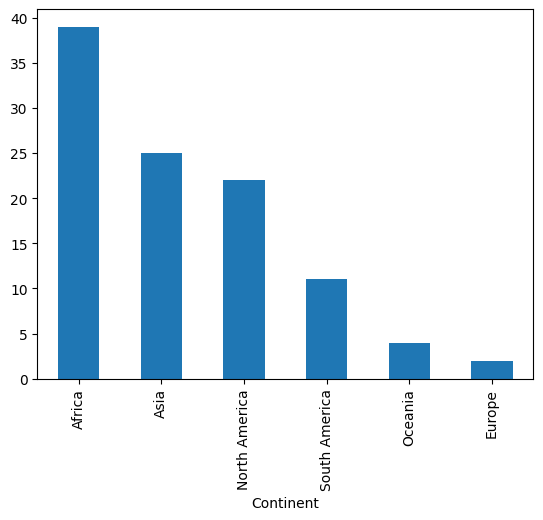

In [24]:
df['Continent'].value_counts().plot(kind = 'bar')

/tmp/ipykernel_525/1188770930.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sea.distplot(df['Production (Tons)'])
/tmp/ipykernel_525/1188770930.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sea.distplot(df['Production_per_person(Kg)'])
/tmp/ipykernel_525/1188770930.py:12: UserWarning: 

`distplot` is a deprec

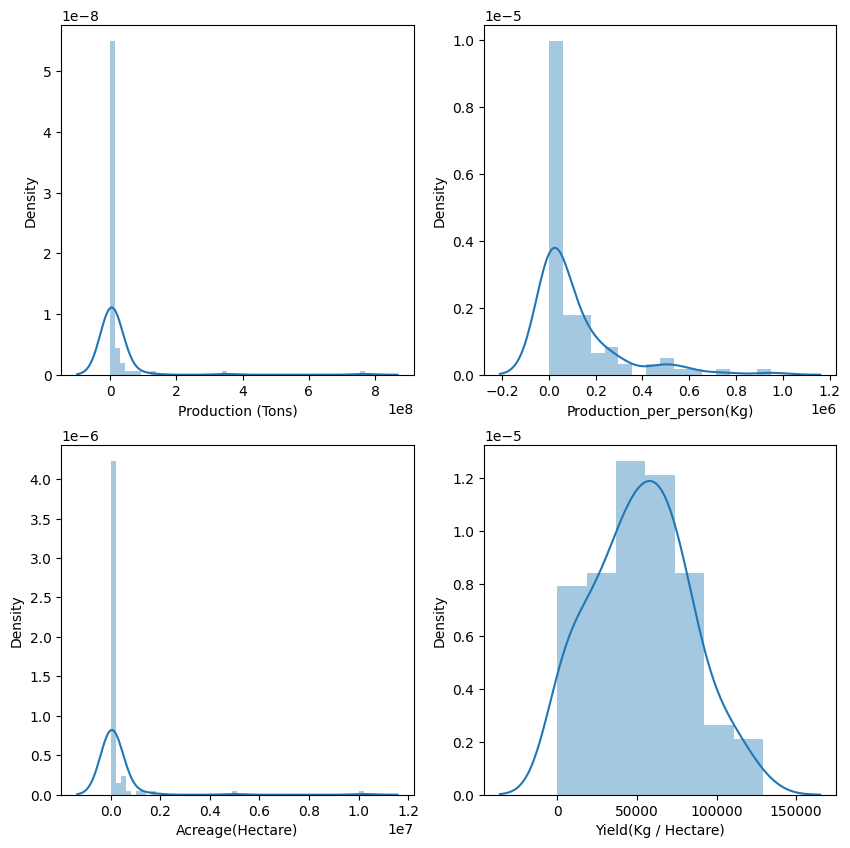

In [25]:
# Check how the data is distributed for numerical columns

plt.figure(figsize = (10,10))

plt.subplot(2,2,1)
sea.distplot(df['Production (Tons)'])

plt.subplot(2,2,2)
sea.distplot(df['Production_per_person(Kg)'])

plt.subplot(2,2,3)
sea.distplot(df['Acreage(Hectare)'])

plt.subplot(2,2,4)
sea.distplot(df['Yield(Kg / Hectare)'])

plt.show()

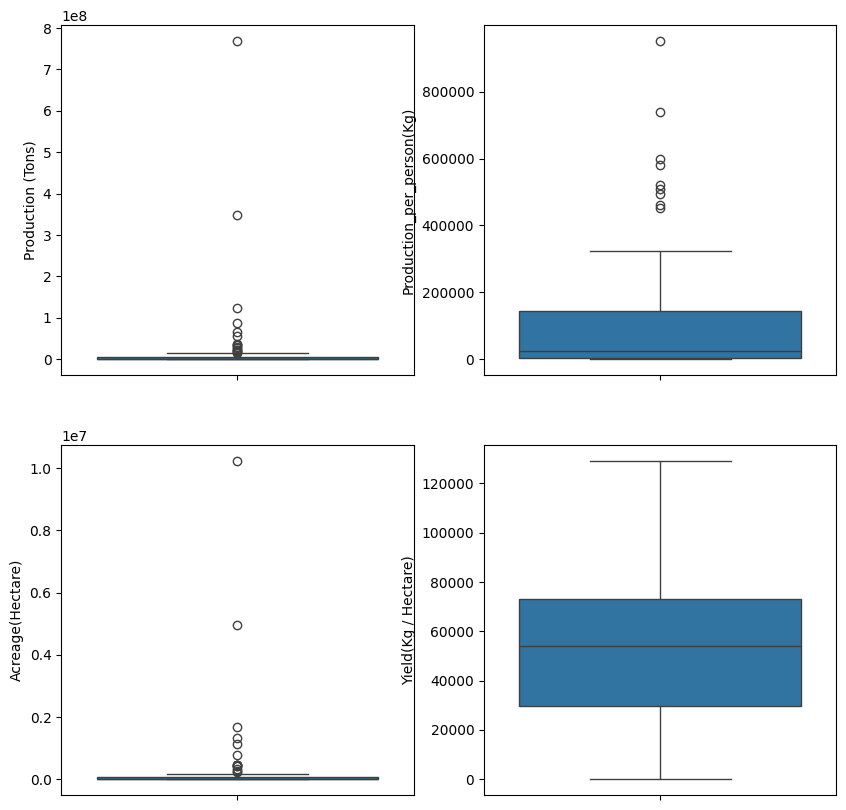

In [26]:
# Check for Outliers visually - can be done using the box plot

plt.figure(figsize = (10,10))

plt.subplot(2,2,1)
sea.boxplot(df['Production (Tons)'])

plt.subplot(2,2,2)
sea.boxplot(df['Production_per_person(Kg)'])

plt.subplot(2,2,3)
sea.boxplot(df['Acreage(Hectare)'])

plt.subplot(2,2,4)
sea.boxplot(df['Yield(Kg / Hectare)'])

plt.show()

# Bivariate Analysis

In [27]:
# Q1.Which country produces the highest sugarcane
df.head()

,Country,Continent,Production (Tons),Production_per_person(Kg),Acreage(Hectare),Yield(Kg / Hectare)
0,Brazil,South America,768678382.0,3668.531,10226205.0,75167.5
1,India,Asia,348448000.0,260721.000,4950000.0,70393.5
2,China,Asia,123059739.0,88287.000,1675215.0,73459.1
3,Thailand,Asia,87468496.0,1264.303,1336575.0,65442.2
4,Pakistan,Asia,65450704.0,324219.000,1130820.0,57879.0


In [28]:
# Here we need to work on the Country column and the Production(Tons) column

df_new = df[['Country','Production (Tons)']].set_index('Country')

In [29]:
df_new.head()

,Production (Tons)
Country,
Brazil,768678382.0
India,348448000.0
China,123059739.0
Thailand,87468496.0
Pakistan,65450704.0


In [30]:
# Introduce a new column named production percentage so that you know how much percent of 
# sugarcane each country is producing

df_new['Production_Percent'] = (df_new['Production (Tons)'] * 100) / (df_new['Production (Tons)'].sum())

In [31]:
df_new.head()

,Production (Tons),Production_Percent
Country,,
Brazil,768678382.0,40.727284
India,348448000.0,18.462001
China,123059739.0,6.520138
Thailand,87468496.0,4.634389
Pakistan,65450704.0,3.467809


<Axes: >

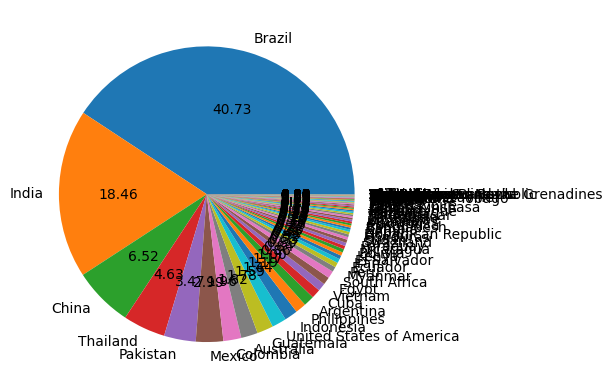

In [32]:
# Plot a bar char to know visually

df_new['Production_Percent'].plot(kind = "pie", autopct = '%.2f')

<Axes: >

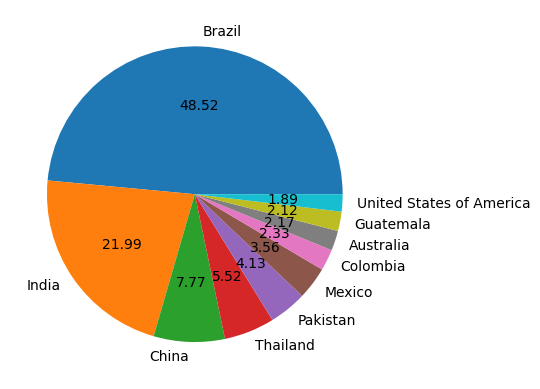

In [33]:
df_new['Production_Percent'].head(10).plot(kind = "pie", autopct = '%.2f')

<Axes: xlabel='Country', ylabel='Acreage(Hectare)'>

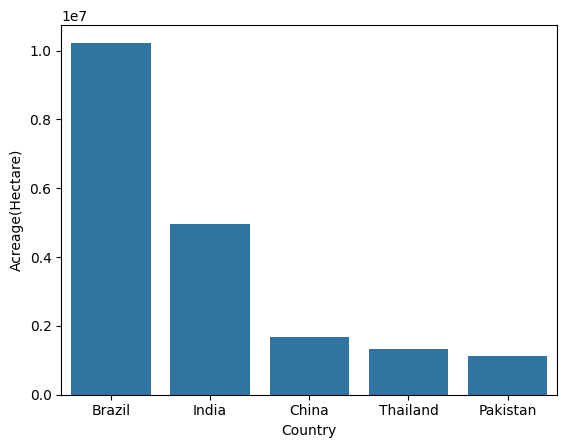

In [34]:
# Q2 Which country has the highest land

sea.barplot(data = df.head(5), x = 'Country', y = 'Acreage(Hectare)')

In [35]:
# Q3 Which country has the highest production

df_new.sort_values(by='Production (Tons)', ascending=False).head(1)


,Production (Tons),Production_Percent
Country,,
Brazil,768678382.0,40.727284


## Correlation


In [36]:
#df.corr()
df.corr(numeric_only=True)

,Production (Tons),Production_per_person(Kg),Acreage(Hectare),Yield(Kg / Hectare)
Production (Tons),1.000000,0.016341,0.997550,0.132675
Production_per_person(Kg),0.016341,1.000000,0.013813,0.017659
Acreage(Hectare),0.997550,0.013813,1.000000,0.113310
Yield(Kg / Hectare),0.132675,0.017659,0.113310,1.000000


<Axes: >

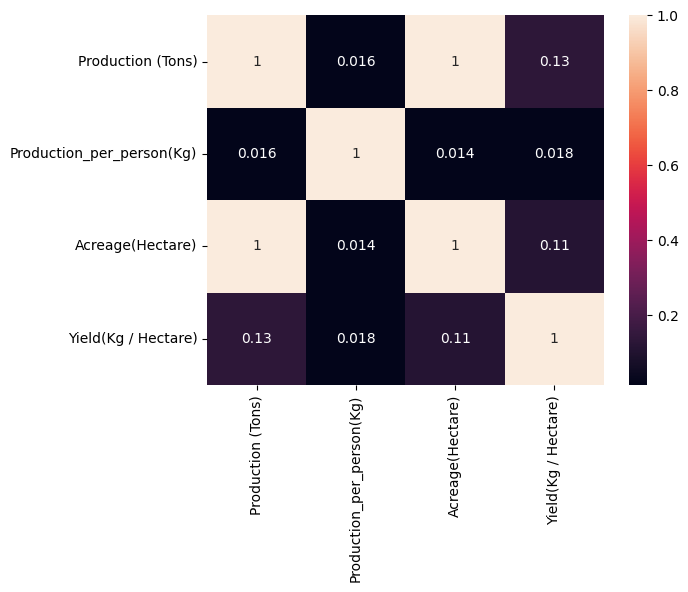

In [37]:
sea.heatmap(df.corr(numeric_only = True), annot = True)

<Axes: xlabel='Acreage(Hectare)', ylabel='Production (Tons)'>

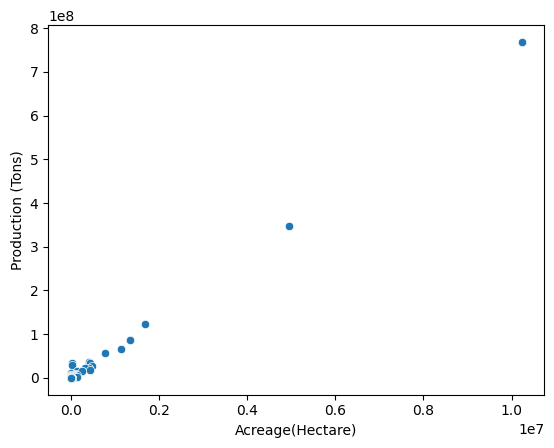

In [38]:
# Q4. Do countries with the highest land produce more sugarcane

sea.scatterplot(data = df, x = 'Acreage(Hectare)' , y = 'Production (Tons)')

<Axes: xlabel='Yield(Kg / Hectare)', ylabel='Production (Tons)'>

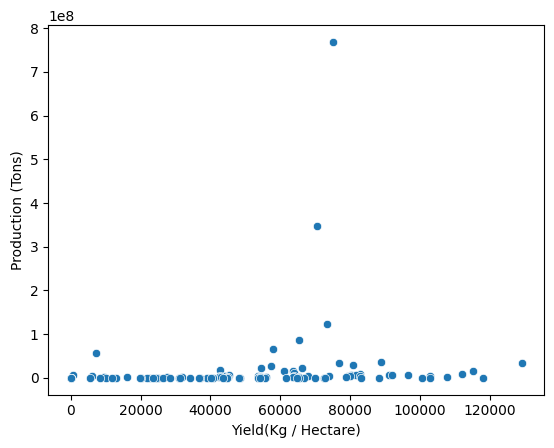

In [39]:
# Q5 Do countries which yield more sugarcane per hectare produce more sugarcane in total?

sea.scatterplot(data = df, x = 'Yield(Kg / Hectare)' , y = 'Production (Tons)')

# Analysis For Continent

In [40]:
df_continent = df.groupby('Continent').sum()

In [41]:
df_continent

,Country,Production (Tons),Production_per_person(Kg),Acreage(Hectare),Yield(Kg / Hectare)
Continent,,,,,
Africa,EgyptSouth AfricaKenyaSwazilandSudanZambiaMaur...,89681525.0,2332687.293,1455647.0,2196216.45
Asia,IndiaChinaThailandPakistanIndonesiaPhilippines...,721930425.0,1857769.303,10608319.0,1171871.40
Europe,PortugalSpain,5823.0,536.000,71.0,131870.90
North America,MexicoGuatemalaUnited States of AmericaCubaEl ...,173995947.0,3796081.508,1581983.0,1082602.40
Oceania,AustraliaFijiPapua New GuineaSamoa,36177574.0,28593.605,490909.0,162419.10
South America,BrazilColombiaArgentinaPeruEcuadorBoliviaParag...,865588126.0,3505531.738,11369236.0,677192.70


<Axes: xlabel='Continent'>

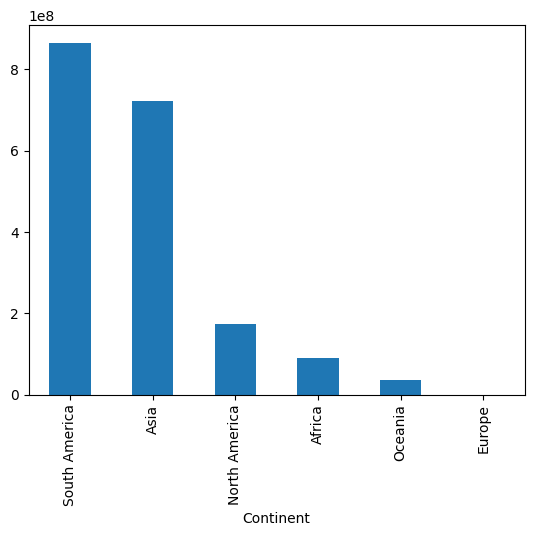

In [42]:
# Q1 Which continent produces maximum sugar

df_continent['Production (Tons)'].sort_values(ascending = False).plot(kind = 'bar')